# Notebook 03 — Evaluation (Kaggle Edition)

## Final Offline Evaluation on the Official MINDsmall_dev Split

**Evaluation only.** This notebook never retrains Logistic Regression or LightGBM, never
rebuilds the ranker training dataset for training, and never overwrites train embeddings,
the train NewsID mapping, or the train FAISS index. It **loads** the artifacts trained in
`02_Model_Development.ipynb` and evaluates four ranking strategies — Popularity,
Heuristic Hybrid, Logistic Regression, LightGBM — on `MINDsmall_dev`.

**Separate-session assumption:** this notebook does NOT assume `/kaggle/working` from
Notebook 02 persists. It expects the Notebook 02 **output** (containing
`notebook02_artifacts/manifest.json`) to be attached as a Kaggle dataset input. If that
bundle isn't found, this notebook fails immediately with a clear message rather than
silently retraining anything.

## 0. Kaggle Evaluation Environment Setup

In [4]:
import importlib, subprocess, sys

REQUIRED_PACKAGES = ["faiss-cpu", "lightgbm", "sentence-transformers", "scikit-learn"]
IMPORT_NAMES = {"faiss-cpu": "faiss", "lightgbm": "lightgbm",
                "sentence-transformers": "sentence_transformers", "scikit-learn": "sklearn"}

for pkg in REQUIRED_PACKAGES:
    mod_name = IMPORT_NAMES[pkg]
    try:
        importlib.import_module(mod_name)
        print(f"OK  {pkg} already available")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        print(f"Installed {pkg}")


OK  faiss-cpu already available
OK  lightgbm already available
OK  sentence-transformers already available
OK  scikit-learn already available


In [5]:
import os
from pathlib import Path

def resolve_kaggle_datasets():
    """
    Deterministically locate the three separately-attached Kaggle datasets by
    walking /kaggle/input and matching on the exact nested directory name
    (MINDsmall_train, MINDsmall_dev, personalized-news-recommender), verifying
    real files with Path.is_file(). This does NOT do broad recursive
    train/dev guessing across arbitrary datasets -- it only normalizes for
    Kaggle's mount-slug naming.
    """
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("/kaggle/input does not exist -- are you running on Kaggle?")

    train_matches, dev_matches, project_matches = [], [], []

    for top in input_root.iterdir():
        if not top.is_dir():
            continue
        for root, dirs, files in os.walk(top):
            root_path = Path(root)
            name = root_path.name

            if name == "MINDsmall_train":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    train_matches.append(root_path)

            elif name == "MINDsmall_dev":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    dev_matches.append(root_path)

            elif name == "personalized-news-recommender":
                if (root_path / "src").is_dir() and (root_path / "requirements.txt").is_file():
                    project_matches.append(root_path)

    top_level_dirs = [str(p) for p in input_root.iterdir() if p.is_dir()]

    problems = []
    if len(train_matches) == 0:
        problems.append("No real 'MINDsmall_train' directory (with news.tsv + behaviors.tsv) found. "
                         "(Only needed here if train metadata must be re-verified.)")
    if len(dev_matches) == 0:
        problems.append("No real 'MINDsmall_dev' directory (with news.tsv + behaviors.tsv) found.")
    elif len(dev_matches) > 1:
        problems.append(f"Found {len(dev_matches)} candidate MINDsmall_dev directories: {dev_matches}")

    if len(project_matches) == 0:
        problems.append("No real 'personalized-news-recommender' project directory (with src/) found.")
    elif len(project_matches) > 1:
        problems.append(f"Found {len(project_matches)} candidate project directories: {project_matches}")

    if len(dev_matches) == 0 or len(project_matches) == 0:
        raise RuntimeError(
            "Could not deterministically resolve the required Kaggle datasets.\n"
            + "\n".join(problems)
            + f"\n\nTop-level directories under /kaggle/input: {top_level_dirs}\n"
            "Attach the 'MINDsmall_dev' and 'personalized-news-recommender' Kaggle "
            "datasets (plus the Notebook 02 output dataset) to this notebook."
        )

    train_source = train_matches[0] if train_matches else None
    dev_source, project_source = dev_matches[0], project_matches[0]

    for f in (dev_source / "news.tsv", dev_source / "behaviors.tsv"):
        assert f.is_file() and f.stat().st_size > 0, f"Not a real, non-empty file: {f}"
    if train_source is not None:
        assert train_source != dev_source, "TRAIN_SOURCE and DEV_SOURCE resolved to the same directory."

    return train_source, dev_source, project_source


TRAIN_SOURCE, DEV_SOURCE, PROJECT_SOURCE = resolve_kaggle_datasets()
print("TRAIN_SOURCE:  ", TRAIN_SOURCE, "(optional, only used for train metadata re-verification)")
print("DEV_SOURCE:    ", DEV_SOURCE)
print("PROJECT_SOURCE:", PROJECT_SOURCE)


TRAIN_SOURCE:   /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train (optional, only used for train metadata re-verification)
DEV_SOURCE:     /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev
PROJECT_SOURCE: /kaggle/input/datasets/timepassforme01/personalized-news-recommender/personalized-news-recommender


In [6]:
import os
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/personalized-news-recommender")

if not PROJECT_ROOT.exists():
    shutil.copytree(PROJECT_SOURCE, PROJECT_ROOT)
else:
    # Preserve data/ and outputs/ (may already hold restored/trained artifacts in this
    # session); only sync the code itself.
    for subdir in ("src", "app"):
        src_dir, dst_dir = PROJECT_SOURCE / subdir, PROJECT_ROOT / subdir
        if src_dir.exists():
            shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)

assert (PROJECT_ROOT / "src" / "config.py").exists()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

for mod_name in list(sys.modules):
    if mod_name == "src" or mod_name.startswith("src."):
        del sys.modules[mod_name]

from src import config

print("PROJECT_ROOT:", PROJECT_ROOT)
print("config loaded from:", config.__file__)
assert str(config.__file__).startswith(str(PROJECT_ROOT)), "config imported from an unexpected location"


PROJECT_ROOT: /kaggle/working/personalized-news-recommender
config loaded from: /kaggle/working/personalized-news-recommender/src/config.py


## 1. Restore and Verify Notebook 02 Artifacts

Searches attached Kaggle inputs for `notebook02_artifacts/manifest.json` (the bundle
produced at the end of Notebook 02) and restores every file to the exact path
`config.py` expects. **This notebook never retrains models** — if the bundle is missing,
it fails here with an explicit instruction rather than silently training anything.

In [7]:
import json
import pandas as pd

def find_manifest():
    input_root = Path("/kaggle/input")
    for root, dirs, files in os.walk(input_root):
        if "manifest.json" in files and Path(root).name == "notebook02_artifacts":
            return Path(root) / "manifest.json"
    # Fallback: a manifest.json anywhere that looks like ours (has expected keys)
    for root, dirs, files in os.walk(input_root):
        if "manifest.json" in files:
            candidate = Path(root) / "manifest.json"
            try:
                data = json.loads(candidate.read_text())
                if isinstance(data, list) and data and "bundled_filename" in data[0]:
                    return candidate
            except Exception:
                continue
    return None

manifest_path = find_manifest()

if manifest_path is None:
    raise RuntimeError(
        "Notebook 02 trained artifacts were not found.\n"
        "Save Notebook 02 as a Kaggle version (Save & Run All) and attach its output "
        "dataset to this notebook. This notebook does not retrain models."
    )

print("Found manifest:", manifest_path)
manifest = json.loads(manifest_path.read_text())
bundle_dir = manifest_path.parent
pd.DataFrame(manifest)

Found manifest: /kaggle/input/datasets/timepassforme01/notebook02-artifacts/kaggle/working/notebook02_artifacts/manifest.json


,artifact,configured_destination,bundled_filename,size_bytes
0,processed_news,/kaggle/working/personalized-news-recommender/...,processed_news.csv,59758507
1,processed_behaviors,/kaggle/working/personalized-news-recommender/...,processed_behaviors.csv,92019761
2,news_embeddings,/kaggle/working/personalized-news-recommender/...,news_embeddings.npy,78769280
3,news_id_to_idx,/kaggle/working/personalized-news-recommender/...,news_id_to_idx.pkl,606648
4,user_embeddings,/kaggle/working/personalized-news-recommender/...,user_embeddings.npy,75430016
5,user_embeddings_ids,/kaggle/working/personalized-news-recommender/...,user_embeddings_ids.csv,337983
6,faiss_index,/kaggle/working/personalized-news-recommender/...,faiss.index,78769197
7,popularity_scores,/kaggle/working/personalized-news-recommender/...,popularity_scores.csv,202839
8,logreg_model,/kaggle/working/personalized-news-recommender/...,ranker_logreg.pkl,798
9,lightgbm_model,/kaggle/working/personalized-news-recommender/...,ranker_lightgbm.pkl,1755553


In [8]:
for entry in manifest:
    src_path = bundle_dir / entry["bundled_filename"]
    dest_path = Path(entry["configured_destination"])
    # Map the ORIGINAL configured destination onto THIS session's config, in case the
    # DATA_DIR differs -- reconstruct relative to config.DATA_DIR by filename.
    dest_path = config.DATA_DIR / dest_path.name
    dest_path.parent.mkdir(parents=True, exist_ok=True)

    assert src_path.is_file() and src_path.stat().st_size > 0, f"Bundled file missing/empty: {src_path}"
    shutil.copy2(src_path, dest_path)

print(f"Restored {len(manifest)} artifacts into {config.DATA_DIR}")


Restored 10 artifacts into /kaggle/working/personalized-news-recommender/data


In [9]:
REQUIRED_TRAIN_ARTIFACTS = {
    "processed_news": config.PROCESSED_NEWS,
    "processed_behaviors": config.PROCESSED_BEHAVIORS,
    "news_embeddings": config.NEWS_EMBEDDINGS,
    "news_id_to_idx": config.NEWS_ID_TO_IDX_PATH,
    "user_embeddings": config.USER_EMBEDDINGS,
    "user_embeddings_ids": config.USER_EMBEDDINGS_IDS,
    "faiss_index": config.FAISS_INDEX_PATH,
    "popularity_scores": config.POPULARITY_SCORES,
    "logreg_model": config.LOGREG_MODEL_PATH,
    "lightgbm_model": config.LIGHTGBM_MODEL_PATH,
}

def artifact_status(paths: dict) -> pd.DataFrame:
    rows = []
    for name, path in paths.items():
        path = Path(path)
        exists = path.exists() and path.is_file()
        size = path.stat().st_size if exists else 0
        rows.append({"artifact": name, "path": str(path), "exists": exists,
                      "is_file": exists, "size_bytes": size})
    return pd.DataFrame(rows)

status_df = artifact_status(REQUIRED_TRAIN_ARTIFACTS)
display(status_df)

missing = status_df[~status_df["exists"] | (status_df["size_bytes"] == 0)]
if not missing.empty:
    raise RuntimeError(
        "The following Notebook 02 artifacts could not be restored:\n"
        f"{missing.to_string(index=False)}\n\n"
        "Re-check that the Notebook 02 output dataset is attached and contains "
        "notebook02_artifacts/manifest.json with all bundled files."
    )
print("\nAll required Notebook 02 (train) artifacts verified present and non-empty.")

,artifact,path,exists,is_file,size_bytes
0,processed_news,/kaggle/working/personalized-news-recommender/...,True,True,59758507
1,processed_behaviors,/kaggle/working/personalized-news-recommender/...,True,True,92019761
2,news_embeddings,/kaggle/working/personalized-news-recommender/...,True,True,78769280
3,news_id_to_idx,/kaggle/working/personalized-news-recommender/...,True,True,606648
4,user_embeddings,/kaggle/working/personalized-news-recommender/...,True,True,75430016
5,user_embeddings_ids,/kaggle/working/personalized-news-recommender/...,True,True,337983
6,faiss_index,/kaggle/working/personalized-news-recommender/...,True,True,78769197
7,popularity_scores,/kaggle/working/personalized-news-recommender/...,True,True,202839
8,logreg_model,/kaggle/working/personalized-news-recommender/...,True,True,798
9,lightgbm_model,/kaggle/working/personalized-news-recommender/...,True,True,1755553



All required Notebook 02 (train) artifacts verified present and non-empty.


## 2. Official Dev Dataset Setup

In [10]:
print("config.DEV_NEWS:     ", config.DEV_NEWS)
print("config.DEV_BEHAVIORS:", config.DEV_BEHAVIORS)

config.DEV_NEWS.parent.mkdir(parents=True, exist_ok=True)

shutil.copy2(DEV_SOURCE / "news.tsv", config.DEV_NEWS)
shutil.copy2(DEV_SOURCE / "behaviors.tsv", config.DEV_BEHAVIORS)

for f in (config.DEV_NEWS, config.DEV_BEHAVIORS):
    assert f.exists() and f.is_file() and f.stat().st_size > 0, f"Missing or empty: {f}"
    print(f"{f}  ({f.stat().st_size:,} bytes)")

print("\nDev dataset copied to the exact configured destinations (never as train).")


config.DEV_NEWS:      /kaggle/working/personalized-news-recommender/dataset/dev/news.tsv
config.DEV_BEHAVIORS: /kaggle/working/personalized-news-recommender/dataset/dev/behaviors.tsv
/kaggle/working/personalized-news-recommender/dataset/dev/news.tsv  (33,519,092 bytes)
/kaggle/working/personalized-news-recommender/dataset/dev/behaviors.tsv  (42,838,544 bytes)

Dev dataset copied to the exact configured destinations (never as train).


## 3. Imports and Reproducibility

`src.embedding.load_model` and `src.ranker.load_model` share the same function name —
both are imported below with **explicit aliases** so one never silently shadows the
other.

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt

from src.preprocess import run_preprocessing
from src.embedding import load_model as load_embedding_model, encode_news
from src.user_profile import build_news_id_index, get_user_vector
from src.faiss_index import build_faiss_index, save_index
from src.ranking import compute_popularity_scores, recommend_for_user
from src.evaluation import (
    precision_at_k, recall_at_k, ndcg_at_k, hit_rate, average_precision_at_k,
    compute_auc, compute_pr_auc,
)
from src.ranker import (
    build_training_dataset,
    load_model as load_ranker_model,
    evaluate_model as evaluate_ranker_model,
)
from src.utils import save_json

np.random.seed(config.RANDOM_SEED)
K = config.EVAL_K

print("Random seed:", config.RANDOM_SEED)
print("Evaluation K:", K)
print("Sample size (config.EVAL_SAMPLE_SIZE):", config.EVAL_SAMPLE_SIZE)


Random seed: 42
Evaluation K: 10
Sample size (config.EVAL_SAMPLE_SIZE): 2000


## 4. Load Train Artifacts and Models

In [12]:
train_news = pd.read_csv(config.PROCESSED_NEWS)
train_behaviors = pd.read_csv(config.PROCESSED_BEHAVIORS)
train_news_embeddings = np.load(config.NEWS_EMBEDDINGS)
popularity_df = pd.read_csv(config.POPULARITY_SCORES)

logreg_model = load_ranker_model(config.LOGREG_MODEL_PATH, is_lightgbm=False)
lgbm_model = load_ranker_model(config.LIGHTGBM_MODEL_PATH, is_lightgbm=True)

assert not np.isnan(train_news_embeddings).any()
assert not np.isinf(train_news_embeddings).any()
assert train_news_embeddings.shape[0] == len(train_news)

print("train_news:            ", train_news.shape)
print("train_behaviors:       ", train_behaviors.shape)
print("train_news_embeddings: ", train_news_embeddings.shape)
print("popularity_df:         ", popularity_df.shape)
print("logreg_model:          ", type(logreg_model).__name__)
print("lgbm_model:            ", type(lgbm_model).__name__,
      "| best_iteration =", lgbm_model.best_iteration)


train_news:             (51282, 9)
train_behaviors:        (156965, 5)
train_news_embeddings:  (51282, 384)
popularity_df:          (7713, 2)
logreg_model:           LogisticRegression
lgbm_model:             Booster | best_iteration = -1


## 5. Prepare Official Dev Data

Uses `run_preprocessing` with **explicit dev-specific paths** (`config.DEV_NEWS`,
`config.DEV_BEHAVIORS` as input; `config.DEV_PROCESSED_NEWS`,
`config.DEV_PROCESSED_BEHAVIORS` as output) — this never touches the train processed
CSVs, since the destination paths are passed explicitly rather than relying on the
function's train-path defaults.

In [13]:
dev_news, dev_behaviors = run_preprocessing(
    news_path=config.DEV_NEWS,
    behaviors_path=config.DEV_BEHAVIORS,
    save=True,
    processed_news_path=config.DEV_PROCESSED_NEWS,
    processed_behaviors_path=config.DEV_PROCESSED_BEHAVIORS,
)

empty_history = (dev_behaviors["History"] == "").sum()

print("Dev news shape:      ", dev_news.shape)
print("Dev behavior shape:  ", dev_behaviors.shape)
print("Unique dev users:    ", dev_behaviors["UserID"].nunique())
print("Dev impression rows: ", len(dev_behaviors))
print(f"Empty-history rows:  {empty_history} ({empty_history / len(dev_behaviors):.1%})")

# Confirm train processed files were NOT touched by this call
assert pd.read_csv(config.PROCESSED_NEWS).shape == train_news.shape, \
    "Train processed news was unexpectedly modified!"
print("\nConfirmed: train processed artifacts were not modified by dev preprocessing.")


2026-07-14 20:51:45 | INFO     | news_recommender | Loaded news file: /kaggle/working/personalized-news-recommender/dataset/dev/news.tsv -> (42416, 8)
2026-07-14 20:51:46 | INFO     | news_recommender | Loaded behaviors file: /kaggle/working/personalized-news-recommender/dataset/dev/behaviors.tsv -> (73152, 5)
2026-07-14 20:51:48 | INFO     | news_recommender | Saved processed news to /kaggle/working/personalized-news-recommender/data/dev_processed_news.csv
2026-07-14 20:51:48 | INFO     | news_recommender | Saved processed behaviors to /kaggle/working/personalized-news-recommender/data/dev_processed_behaviors.csv


Dev news shape:       (42416, 9)
Dev behavior shape:   (73152, 5)
Unique dev users:     50000
Dev impression rows:  73152
Empty-history rows:  2214 (3.0%)

Confirmed: train processed artifacts were not modified by dev preprocessing.


## 6. Dev News Embeddings

Uses `load_embedding_model` (the aliased Sentence Transformer loader — not the ranker's
`load_model`). Saved only to `config.DEV_NEWS_EMBEDDINGS`; `config.NEWS_EMBEDDINGS`
(train) is never written here.

In [14]:
embedding_model = load_embedding_model()

t0 = time.time()
dev_news_embeddings = encode_news(dev_news, model=embedding_model)
print(f"Dev embedding took {(time.time() - t0) / 60:.1f} min")

assert dev_news_embeddings.shape[0] == len(dev_news)
assert dev_news_embeddings.shape[1] == train_news_embeddings.shape[1]
assert not np.isnan(dev_news_embeddings).any()
assert not np.isinf(dev_news_embeddings).any()

np.save(config.DEV_NEWS_EMBEDDINGS, dev_news_embeddings)
print("Saved to:", config.DEV_NEWS_EMBEDDINGS, "| shape:", dev_news_embeddings.shape)


2026-07-14 20:51:49 | INFO     | news_recommender | Loading embedding model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/332 [00:00<?, ?it/s]

Dev embedding took 8.2 min
Saved to: /kaggle/working/personalized-news-recommender/data/dev_news_embeddings.npy | shape: (42416, 384)


## 7. Dev NewsID Mapping

In [15]:
dev_news_id_to_idx = build_news_id_index(dev_news, save_path=config.DEV_NEWS_ID_TO_IDX_PATH)
assert len(dev_news_id_to_idx) == len(dev_news)
sample_dev_id = dev_news["NewsID"].iloc[0]
assert dev_news_id_to_idx[sample_dev_id] == 0
print(f"Dev NewsID index size: {len(dev_news_id_to_idx)}")
print("Confirmed saved only to config.DEV_NEWS_ID_TO_IDX_PATH:", config.DEV_NEWS_ID_TO_IDX_PATH)

2026-07-14 21:00:05 | INFO     | news_recommender | Saved NewsID index (42416 entries) to /kaggle/working/personalized-news-recommender/data/dev_news_id_to_idx.pkl


Dev NewsID index size: 42416
Confirmed saved only to config.DEV_NEWS_ID_TO_IDX_PATH: /kaggle/working/personalized-news-recommender/data/dev_news_id_to_idx.pkl


## 8. Dev FAISS Index

In [16]:
dev_index = build_faiss_index(dev_news_embeddings)
save_index(dev_index, path=config.DEV_FAISS_INDEX_PATH)  # never overwrites config.FAISS_INDEX_PATH
assert dev_index.ntotal == len(dev_news_embeddings)
print("Dev FAISS index size:", dev_index.ntotal)
print("Saved only to:", config.DEV_FAISS_INDEX_PATH)

2026-07-14 21:00:05 | INFO     | news_recommender | Built FAISS index: 42416 vectors, dim=384
2026-07-14 21:00:05 | INFO     | news_recommender | Saved FAISS index to /kaggle/working/personalized-news-recommender/data/dev_faiss.index


Dev FAISS index size: 42416
Saved only to: /kaggle/working/personalized-news-recommender/data/dev_faiss.index


**Leakage note:** popularity is deliberately **not** recomputed from `dev_behaviors`
here. Doing so would let the popularity prior "see" the very click labels being
evaluated (the article a user clicked in the impression being scored would already be
baked into its own popularity score), inflating every strategy's dev metrics. Instead,
the **train-derived `popularity_df`** loaded in Section 4 (`config.POPULARITY_SCORES`,
computed in `02_Model_Development.ipynb` from `MINDsmall_train` only) is reused for all
dev-set recommendations below -- exactly as it would be at real serving time, where the
popularity prior is a historical statistic computed before the impression happens.

**Observation:** Dev embeddings, NewsID index, FAISS index, and popularity scores
are all separate artifacts from train — none of the train equivalents were overwritten.

## 9. Evaluation Protocol

- **Official `MINDsmall_dev`** is used for this final evaluation (never during training).
- Impression tokens are parsed with `rsplit("-", 1)`: `N123-1` → clicked/relevant,
  `N456-0` → not clicked/negative.
- **Only label-1 articles count as ground-truth relevant.**
- Each user's profile vector comes from their `History` field (past reads) — the click
  labels of the impression currently being scored are never used to build that user's
  profile, so there is no leakage of the evaluation target into the input.
- All four strategies are evaluated on the **same cohort** with the **same candidate
  protocol** for a fair comparison, at **K = 10**.

In [17]:
def parse_impressions(impressions_str):
    """Parse impression tokens with rsplit to safely get clicked (relevant) NewsIDs."""
    relevant = []
    for entry in str(impressions_str).split():
        try:
            news_id, label = entry.rsplit("-", 1)
        except ValueError:
            continue
        if label == "1":
            relevant.append(news_id)
    return relevant


## 10. Evaluation Cohort

In [18]:
eligible = dev_behaviors[dev_behaviors["Impressions"].apply(
    lambda s: len(parse_impressions(s)) > 0
)]

warm_mask = eligible["History"].fillna("").str.len() > 0
n_warm = int(warm_mask.sum())
n_cold = int((~warm_mask).sum())

sample = eligible.sample(
    n=min(config.EVAL_SAMPLE_SIZE, len(eligible)), random_state=config.RANDOM_SEED
)

print(f"Total dev behavior rows:        {len(dev_behaviors):,}")
print(f"Eligible rows (>=1 relevant):   {len(eligible):,}")
print(f"  warm-start (has history):     {n_warm:,}")
print(f"  cold-start (no history):      {n_cold:,}")
print(f"Evaluation cohort (sampled, seed={config.RANDOM_SEED}): {len(sample):,}")


Total dev behavior rows:        73,152
Eligible rows (>=1 relevant):   73,152
  warm-start (has history):     70,938
  cold-start (no history):      2,214
Evaluation cohort (sampled, seed=42): 2,000


## 11-14. Evaluation Loop

In [19]:
def evaluate(recommend_fn, sample_df, k=K):
    """Run recommend_fn(row) -> list[NewsID] over a behaviors sample and
    aggregate Precision/Recall/NDCG/MAP @k."""
    precisions, recalls, ndcgs, hits, aps = [], [], [], [], []
    for _, row in sample_df.iterrows():
        relevant_ids = parse_impressions(row["Impressions"])
        if not relevant_ids:
            continue
        recommended_ids = recommend_fn(row)
        precisions.append(precision_at_k(recommended_ids, relevant_ids, k=k))
        recalls.append(recall_at_k(recommended_ids, relevant_ids, k=k))
        ndcgs.append(ndcg_at_k(recommended_ids, relevant_ids, k=k))
        hits.append(hit_rate(recommended_ids, relevant_ids, k=k))
        aps.append(average_precision_at_k(recommended_ids, relevant_ids, k=k))
    return {
        "Precision@10": float(np.mean(precisions)) if precisions else 0.0,
        "Recall@10": float(np.mean(recalls)) if recalls else 0.0,
        "NDCG@10": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "HitRate@10": float(np.mean(hits)) if hits else 0.0,
        "MAP@10": float(np.mean(aps)) if aps else 0.0,
        "n": len(precisions),
    }


def popularity_only_recommend(row):
    recs = (
        dev_news.merge(popularity_df, on="NewsID", how="left")
        .fillna({"popularity_score": 0.0})
        .sort_values("popularity_score", ascending=False)
        .head(K)
    )
    return recs["NewsID"].tolist()


def heuristic_recommend(row):
    user_vec = get_user_vector(row["History"], dev_news_id_to_idx, dev_news_embeddings)
    recs = recommend_for_user(
        row["UserID"], user_vec, dev_index, dev_news, popularity_df, top_k=K, ranker="heuristic"
    )
    return recs["NewsID"].tolist()


def logreg_recommend(row):
    user_vec = get_user_vector(row["History"], dev_news_id_to_idx, dev_news_embeddings)
    history_ids = row["History"].split() if isinstance(row["History"], str) and row["History"] else []
    recs = recommend_for_user(
        row["UserID"], user_vec, dev_index, dev_news, popularity_df, top_k=K,
        ranker="ml", model=logreg_model, history_ids=history_ids,
        news_id_to_idx=dev_news_id_to_idx, news_embeddings=dev_news_embeddings,
    )
    return recs["NewsID"].tolist()


def lgbm_recommend(row):
    user_vec = get_user_vector(row["History"], dev_news_id_to_idx, dev_news_embeddings)
    history_ids = row["History"].split() if isinstance(row["History"], str) and row["History"] else []
    recs = recommend_for_user(
        row["UserID"], user_vec, dev_index, dev_news, popularity_df, top_k=K,
        ranker="ml", model=lgbm_model, history_ids=history_ids,
        news_id_to_idx=dev_news_id_to_idx, news_embeddings=dev_news_embeddings,
    )
    return recs["NewsID"].tolist()


In [20]:
t0 = time.time()
baseline_results = evaluate(popularity_only_recommend, sample)
print(f"[11] Popularity done in {time.time() - t0:.1f}s:", baseline_results)

[11] Popularity done in 57.6s: {'Precision@10': 0.00045000000000000004, 'Recall@10': 0.003625, 'NDCG@10': 0.0012218830247379998, 'HitRate@10': 0.0045, 'MAP@10': 0.0004704861111111111, 'n': 2000}


In [21]:
t0 = time.time()
heuristic_results = evaluate(heuristic_recommend, sample)
print(f"[12] Heuristic done in {time.time() - t0:.1f}s:", heuristic_results)

[12] Heuristic done in 22.5s: {'Precision@10': 0.0016, 'Recall@10': 0.010784523809523808, 'NDCG@10': 0.00602429624533411, 'HitRate@10': 0.016, 'MAP@10': 0.003948227513227513, 'n': 2000}


In [22]:
t0 = time.time()
logreg_ranking_results = evaluate(logreg_recommend, sample)
print(f"[13] Logistic Regression done in {time.time() - t0:.1f}s:", logreg_ranking_results)

[13] Logistic Regression done in 70.2s: {'Precision@10': 0.0010500000000000002, 'Recall@10': 0.007476190476190476, 'NDCG@10': 0.004555610993917391, 'HitRate@10': 0.0105, 'MAP@10': 0.0031615079365079363, 'n': 2000}


In [23]:
t0 = time.time()
lgbm_ranking_results = evaluate(lgbm_recommend, sample)
print(f"[14] LightGBM done in {time.time() - t0:.1f}s:", lgbm_ranking_results)

[14] LightGBM done in 73.0s: {'Precision@10': 0.0014000000000000002, 'Recall@10': 0.008913690476190474, 'NDCG@10': 0.005921858818468424, 'HitRate@10': 0.0135, 'MAP@10': 0.004366517857142857, 'n': 2000}


### Click-Prediction ROC-AUC / PR-AUC (Logistic Regression & LightGBM only)

Built via `src.ranker.build_training_dataset` on dev data — the same feature logic used
for training (`src.features`), so train and dev features are computed identically. No
retraining occurs; only `evaluate_ranker_model` (aliased `evaluate_model` from
`src.ranker`) is called against the already-loaded models.

In [24]:
t0 = time.time()
dev_ranker_dataset = build_training_dataset(
    dev_behaviors, dev_news, dev_news_id_to_idx, dev_news_embeddings, popularity_df
)
print(f"Built dev ranker feature dataset in {(time.time() - t0) / 60:.1f} min -- {dev_ranker_dataset.shape}")

logreg_auc_metrics = evaluate_ranker_model(logreg_model, dev_ranker_dataset, is_lightgbm=False)
lgbm_auc_metrics = evaluate_ranker_model(lgbm_model, dev_ranker_dataset, is_lightgbm=True)

print("Logistic Regression:", logreg_auc_metrics)
print("LightGBM:           ", lgbm_auc_metrics)

2026-07-14 21:09:09 | INFO     | news_recommender | Built training dataset: 521467 rows (20.7% positive)


Built dev ranker feature dataset in 5.3 min -- (521467, 12)
Logistic Regression: {'roc_auc': 0.6373499111339364, 'pr_auc': 0.3097450578324655}
LightGBM:            {'roc_auc': 0.5985982003188032, 'pr_auc': 0.3022824598737591}


## 15. Four-Strategy Comparison

In [25]:
comparison = pd.DataFrame([
    {"Strategy": "Popularity", **baseline_results,
     "ROC-AUC": float("nan"), "PR-AUC": float("nan")},
    {"Strategy": "Heuristic Hybrid", **heuristic_results,
     "ROC-AUC": float("nan"), "PR-AUC": float("nan")},
    {"Strategy": "Logistic Regression", **logreg_ranking_results,
     "ROC-AUC": logreg_auc_metrics["roc_auc"], "PR-AUC": logreg_auc_metrics["pr_auc"]},
    {"Strategy": "LightGBM", **lgbm_ranking_results,
     "ROC-AUC": lgbm_auc_metrics["roc_auc"], "PR-AUC": lgbm_auc_metrics["pr_auc"]},
]).drop(columns="n")

best_ndcg = comparison.sort_values("NDCG@10", ascending=False).iloc[0]["Strategy"]
best_map = comparison.sort_values("MAP@10", ascending=False).iloc[0]["Strategy"]

print(f"Best strategy by NDCG@10: {best_ndcg}")
print(f"Best strategy by MAP@10:  {best_map}")
comparison

Best strategy by NDCG@10: Heuristic Hybrid
Best strategy by MAP@10:  LightGBM


,Strategy,Precision@10,Recall@10,NDCG@10,HitRate@10,MAP@10,ROC-AUC,PR-AUC
0,Popularity,0.00045,0.003625,0.001222,0.0045,0.000470,NaN,NaN
1,Heuristic Hybrid,0.00160,0.010785,0.006024,0.0160,0.003948,NaN,NaN
2,Logistic Regression,0.00105,0.007476,0.004556,0.0105,0.003162,0.637350,0.309745
3,LightGBM,0.00140,0.008914,0.005922,0.0135,0.004367,0.598598,0.302282


## 16. Ranking Metric Visualization

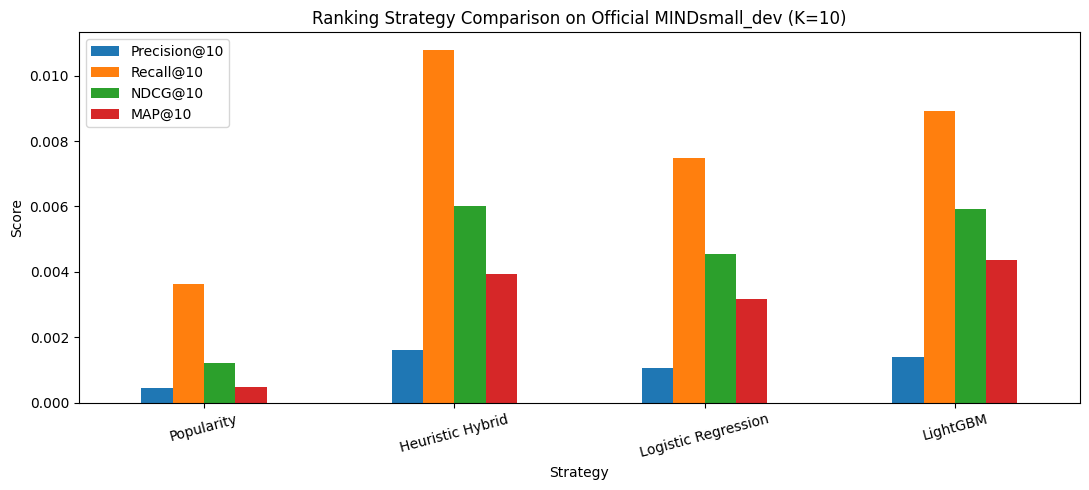

In [26]:
ranking_metrics_only = comparison[["Strategy", "Precision@10", "Recall@10", "NDCG@10", "MAP@10"]]
ranking_metrics_only.set_index("Strategy").plot(kind="bar", figsize=(11, 5))
plt.title("Ranking Strategy Comparison on Official MINDsmall_dev (K=10)")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "ranker_comparison.png", dpi=150)
plt.show()

## 17. ROC-AUC and PR-AUC Comparison

,Strategy,ROC-AUC,PR-AUC
2,Logistic Regression,0.637350,0.309745
3,LightGBM,0.598598,0.302282


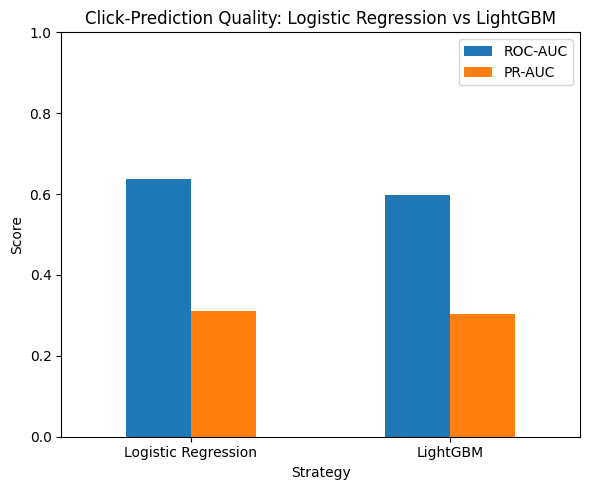

In [27]:
auc_comparison = comparison[comparison["Strategy"].isin(["Logistic Regression", "LightGBM"])][
    ["Strategy", "ROC-AUC", "PR-AUC"]
]
display(auc_comparison)

auc_comparison.set_index("Strategy").plot(kind="bar", figsize=(6, 5))
plt.title("Click-Prediction Quality: Logistic Regression vs LightGBM")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "auc_comparison.png", dpi=150)
plt.show()

## 18. Warm vs Cold-Start Analysis (LightGBM)

Cold-start users are handled by the popularity fallback already implemented inside
`recommend_for_user` — no empty profile is ever forced through FAISS.

In [28]:
warm_sample = sample[sample["History"].fillna("").str.len() > 0]
cold_sample = sample[sample["History"].fillna("").str.len() == 0]

warm_results = evaluate(lgbm_recommend, warm_sample) if len(warm_sample) else {}
cold_results = evaluate(lgbm_recommend, cold_sample) if len(cold_sample) else {}

warm_cold_df = pd.DataFrame([
    {"Segment": "Warm-start", "n_users": len(warm_sample), **warm_results},
    {"Segment": "Cold-start", "n_users": len(cold_sample), **cold_results},
])
warm_cold_df

,Segment,n_users,Precision@10,Recall@10,NDCG@10,HitRate@10,MAP@10,n
0,Warm-start,1931,0.001398,0.008714,0.005978,0.013465,0.004465,1931
1,Cold-start,69,0.001449,0.014493,0.004363,0.014493,0.001610,69


## 19. Exploratory: Performance by User's Dominant History Category

**This is exploratory, not a rigorous per-category metric** — users often read across
multiple categories, so grouping by their single most common history category is a rough
lens. Counts are shown so small groups aren't overinterpreted.

In [29]:
category_scores = {}
for _, row in sample.iterrows():
    relevant_ids = parse_impressions(row["Impressions"])
    hist_ids = row["History"].split() if isinstance(row["History"], str) and row["History"] else []
    if not relevant_ids or not hist_ids:
        continue
    recommended_ids = lgbm_recommend(row)
    top_cat_series = dev_news[dev_news["NewsID"].isin(hist_ids)]["Category"].mode()
    if len(top_cat_series):
        category_scores.setdefault(top_cat_series.iloc[0], []).append({
            "precision": precision_at_k(recommended_ids, relevant_ids, k=K),
            "recall": recall_at_k(recommended_ids, relevant_ids, k=K),
            "ndcg": ndcg_at_k(recommended_ids, relevant_ids, k=K),
            "map": average_precision_at_k(recommended_ids, relevant_ids, k=K),
        })

cat_rows = []
for cat, scores in category_scores.items():
    cat_rows.append({
        "Category": cat,
        "NumEvaluated": len(scores),
        "Precision@10": np.mean([s["precision"] for s in scores]),
        "Recall@10": np.mean([s["recall"] for s in scores]),
        "NDCG@10": np.mean([s["ndcg"] for s in scores]),
        "MAP@10": np.mean([s["map"] for s in scores]),
    })

cat_perf = pd.DataFrame(cat_rows).sort_values("NDCG@10", ascending=False).reset_index(drop=True)
cat_perf

,Category,NumEvaluated,Precision@10,Recall@10,NDCG@10,MAP@10
0,entertainment,47,0.004255,0.024316,0.024201,0.022290
1,foodanddrink,106,0.002830,0.016509,0.013087,0.010908
2,autos,77,0.001299,0.012987,0.012987,0.012987
3,tv,75,0.002667,0.020000,0.009830,0.005556
4,lifestyle,181,0.002210,0.016575,0.006036,0.002477
5,news,944,0.001059,0.006135,0.005021,0.003998
6,health,64,0.001563,0.007812,0.004790,0.002604
7,sports,296,0.001014,0.006757,0.003500,0.001971
8,finance,90,0.001111,0.001587,0.001182,0.000317
9,movies,24,0.000000,0.000000,0.000000,0.000000


## 20. Qualitative Analysis

**Deterministic selection rule:** scan the evaluation sample in order; the success case
is the first row with at least one top-10 hit, the failure case is the first row with
zero top-10 hits. No user was hand-picked for looking good.

In [30]:
success_case, failure_case = None, None

for _, row in sample.iterrows():
    relevant_ids = parse_impressions(row["Impressions"])
    if not relevant_ids:
        continue
    recommended_ids = lgbm_recommend(row)
    hit = len(set(recommended_ids[:K]) & set(relevant_ids)) > 0

    if hit and success_case is None:
        success_case = (row, recommended_ids, relevant_ids)
    if not hit and failure_case is None:
        failure_case = (row, recommended_ids, relevant_ids)
    if success_case and failure_case:
        break

def show_case(label, case):
    if case is None:
        print(f"--- {label}: no example found in this sample ---")
        return
    row, recommended_ids, relevant_ids = case
    hist_ids = row["History"].split() if isinstance(row["History"], str) and row["History"] else []
    hist_cats = dev_news[dev_news["NewsID"].isin(hist_ids)]["Category"].value_counts()
    rec_rows = dev_news[dev_news["NewsID"].isin(recommended_ids)][["NewsID", "Category", "Title"]]

    print(f"--- {label} --- (UserID: {row['UserID']})")
    print("History categories:\n", hist_cats)
    print("\nTop LightGBM recommendations:")
    display(rec_rows)
    print("Actually clicked (relevant) NewsIDs:", relevant_ids)
    print()

show_case("SUCCESS", success_case)
show_case("FAILURE", failure_case)

--- SUCCESS --- (UserID: U53698)
History categories:
 Category
news            14
sports           5
foodanddrink     2
movies           1
Name: count, dtype: int64

Top LightGBM recommendations:


,NewsID,Category,Title
3578,N39885,news,Today in History: October 24
11085,N51257,news,Today in History: November 6
19250,N45324,news,Today in History: November 8
19927,N31225,news,Today in History: October 23
28581,N6785,news,Today in History: November 5
30567,N902,news,Today in History: October 19
36496,N30562,news,Today in History: November 16
36575,N22855,news,"Popular New York high school football coach, t..."
40768,N27908,news,Today in History: November 15
42290,N1480,news,A Yale grad and ex-banker ended up homeless in...


Actually clicked (relevant) NewsIDs: ['N27908']

--- FAILURE --- (UserID: U4285)
History categories:
 Category
news             3
entertainment    1
sports           1
foodanddrink     1
Name: count, dtype: int64

Top LightGBM recommendations:


,NewsID,Category,Title
3395,N46818,news,New York Senator Chuck Schumer Mocks Trump Mak...
6043,N22729,sports,Rob Gronkowski Finally Gives Direct Answer Abo...
8868,N20142,news,"After criticizing Chicago from afar, President..."
9012,N50625,video,RNC chairwoman on President Trump dismissing r...
26466,N13667,sports,"Brian Flores definitely will be back in 2020, ..."
27151,N16441,video,Amy Klobuchar says her moderate approach makes...
34541,N49572,video,I don't believe anymore that they love our cou...
37204,N1573,sports,NFL could meet with Brown multiple times to di...
38858,N19316,news,"Freeze Warning, Drive-By Shooting, Trump Visit..."
42223,N41090,news,Trump Courts 2020 Black Vote Betting Job Gains...


Actually clicked (relevant) NewsIDs: ['N31958', 'N17807']



## 21. Save Evaluation Results

In [31]:
evaluation_output = {
    "evaluation_k": K,
    "evaluation_count": len(sample),
    "strategies": {
        "popularity": baseline_results,
        "heuristic": heuristic_results,
        "logistic_regression": {**logreg_ranking_results, **logreg_auc_metrics},
        "lightgbm": {**lgbm_ranking_results, **lgbm_auc_metrics},
    },
    "warm_users": {"n_users": len(warm_sample), **warm_results},
    "cold_start_users": {"n_users": len(cold_sample), **cold_results},
    "best_strategy_by_ndcg10": best_ndcg,
    "best_strategy_by_map10": best_map,
}

save_json(evaluation_output, config.METRICS_PATH)
comparison.to_csv(config.OUTPUTS_DIR / "strategy_comparison.csv", index=False)
cat_perf.to_csv(config.OUTPUTS_DIR / "category_performance.csv", index=False)

print(f"Saved metrics JSON to:         {config.METRICS_PATH}")
print(f"Saved strategy comparison to:  {config.OUTPUTS_DIR / 'strategy_comparison.csv'}")
print(f"Saved category performance to: {config.OUTPUTS_DIR / 'category_performance.csv'}")

2026-07-14 21:11:42 | INFO     | news_recommender | Saved JSON to /kaggle/working/personalized-news-recommender/outputs/metrics/metrics.json


Saved metrics JSON to:         /kaggle/working/personalized-news-recommender/outputs/metrics/metrics.json
Saved strategy comparison to:  /kaggle/working/personalized-news-recommender/outputs/strategy_comparison.csv
Saved category performance to: /kaggle/working/personalized-news-recommender/outputs/category_performance.csv


In [32]:
qualitative_rows = []
for label, case in [("success", success_case), ("failure", failure_case)]:
    if case is None:
        continue
    row, recommended_ids, relevant_ids = case
    qualitative_rows.append({
        "case_type": label,
        "user_id": row["UserID"],
        "recommended_ids": recommended_ids,
        "relevant_ids": relevant_ids,
    })

if qualitative_rows:
    qual_df = pd.DataFrame(qualitative_rows)
    qual_path = config.RECOMMENDATIONS_DIR / "qualitative_examples.csv"
    qual_df.to_csv(qual_path, index=False)
    print("Saved qualitative examples to:", qual_path)

Saved qualitative examples to: /kaggle/working/personalized-news-recommender/outputs/recommendations/qualitative_examples.csv


## 22. Output Verification

In [33]:
eval_outputs = {
    "metrics_json": config.METRICS_PATH,
    "strategy_comparison_csv": config.OUTPUTS_DIR / "strategy_comparison.csv",
    "category_performance_csv": config.OUTPUTS_DIR / "category_performance.csv",
    "ranker_comparison_figure": config.FIGURES_DIR / "ranker_comparison.png",
    "auc_comparison_figure": config.FIGURES_DIR / "auc_comparison.png",
}

eval_status_df = artifact_status(eval_outputs)
display(eval_status_df)

critical_missing = eval_status_df[
    (eval_status_df["artifact"] == "metrics_json") &
    (~eval_status_df["exists"] | (eval_status_df["size_bytes"] == 0))
]
assert critical_missing.empty, "metrics.json was not saved correctly."
print("\nCritical output (metrics.json) verified present and non-empty.")

,artifact,path,exists,is_file,size_bytes
0,metrics_json,/kaggle/working/personalized-news-recommender/...,True,True,1735
1,strategy_comparison_csv,/kaggle/working/personalized-news-recommender/...,True,True,553
2,category_performance_csv,/kaggle/working/personalized-news-recommender/...,True,True,987
3,ranker_comparison_figure,/kaggle/working/personalized-news-recommender/...,True,True,72231
4,auc_comparison_figure,/kaggle/working/personalized-news-recommender/...,True,True,36917



Critical output (metrics.json) verified present and non-empty.


## 23. Final Evaluation Summary

In [34]:
print("=" * 70)
print("NOTEBOOK 03 -- FINAL EVALUATION SUMMARY (Official MINDsmall_dev)")
print("=" * 70)
print(f"Evaluation cohort size:  {len(sample):,} (K={K})")
print()
print(comparison[["Strategy", "Precision@10", "Recall@10", "NDCG@10", "MAP@10"]]
      .to_string(index=False))
print()
print(f"Logistic Regression:  ROC-AUC={logreg_auc_metrics['roc_auc']:.4f}  "
      f"PR-AUC={logreg_auc_metrics['pr_auc']:.4f}")
print(f"LightGBM:              ROC-AUC={lgbm_auc_metrics['roc_auc']:.4f}  "
      f"PR-AUC={lgbm_auc_metrics['pr_auc']:.4f}")
print()
print(f"Best strategy by NDCG@10: {best_ndcg}")
print(f"Best strategy by MAP@10:  {best_map}")
print()
print(f"Warm-start ({len(warm_sample)} users):  NDCG@10={warm_results.get('NDCG@10', float('nan')):.4f}")
print(f"Cold-start ({len(cold_sample)} users):  NDCG@10={cold_results.get('NDCG@10', float('nan')):.4f}")
print("=" * 70)

NOTEBOOK 03 -- FINAL EVALUATION SUMMARY (Official MINDsmall_dev)
Evaluation cohort size:  2,000 (K=10)

           Strategy  Precision@10  Recall@10  NDCG@10   MAP@10
         Popularity       0.00045   0.003625 0.001222 0.000470
   Heuristic Hybrid       0.00160   0.010785 0.006024 0.003948
Logistic Regression       0.00105   0.007476 0.004556 0.003162
           LightGBM       0.00140   0.008914 0.005922 0.004367

Logistic Regression:  ROC-AUC=0.6373  PR-AUC=0.3097
LightGBM:              ROC-AUC=0.5986  PR-AUC=0.3023

Best strategy by NDCG@10: Heuristic Hybrid
Best strategy by MAP@10:  LightGBM

Warm-start (1931 users):  NDCG@10=0.0060
Cold-start (69 users):  NDCG@10=0.0044


## Conclusion

*(Write this paragraph using the actual printed numbers above once the notebook has run
end to end. State which strategy had the best NDCG@10 and MAP@10 and by how much versus
the heuristic and popularity baselines, which of Logistic Regression / LightGBM had
better ROC-AUC/PR-AUC, and the size of the warm-start vs cold-start gap. Do not state
"LightGBM performed best" unless the Section 15 table actually shows it.)*

## 24. Limitations

- **Offline evaluation only** — these metrics come from historical logs, not a live
  online A/B test; production behavior (position bias, novelty effects) could differ.
- **MIND dataset scope** — English-language Microsoft News users over a fixed short time
  window; may not generalize to other publishers, languages, or periods.
- **Pretrained, not fine-tuned, embeddings** — `all-MiniLM-L6-v2` used as-is; a
  domain-fine-tuned encoder (e.g. contrastive training on MIND click pairs) would likely
  improve retrieval further.
- **Click history as implicit feedback** — a click is a proxy for interest, not a direct
  preference signal; a click doesn't guarantee satisfaction, and a non-click doesn't
  guarantee disinterest.
- **Negative sampling** — ranker training used a fixed negative:positive ratio
  (`config.NEGATIVE_SAMPLING_RATIO`) rather than every negative, trading off training
  speed against potentially missing some negative patterns.
- **Candidate-pool ranking vs official per-impression ranking** — this evaluation ranks
  FAISS-retrieved candidates rather than strictly the exact candidate list of each
  impression as the official MIND benchmark protocol does; a deliberate simplification.
- **Cold-start relies entirely on popularity** — no personalization signal until a user
  builds up click history.
- **No contextual features** — device type, time-of-day, geography, and session context
  are not used, though they matter in production recommenders.